## Exercise 2.1


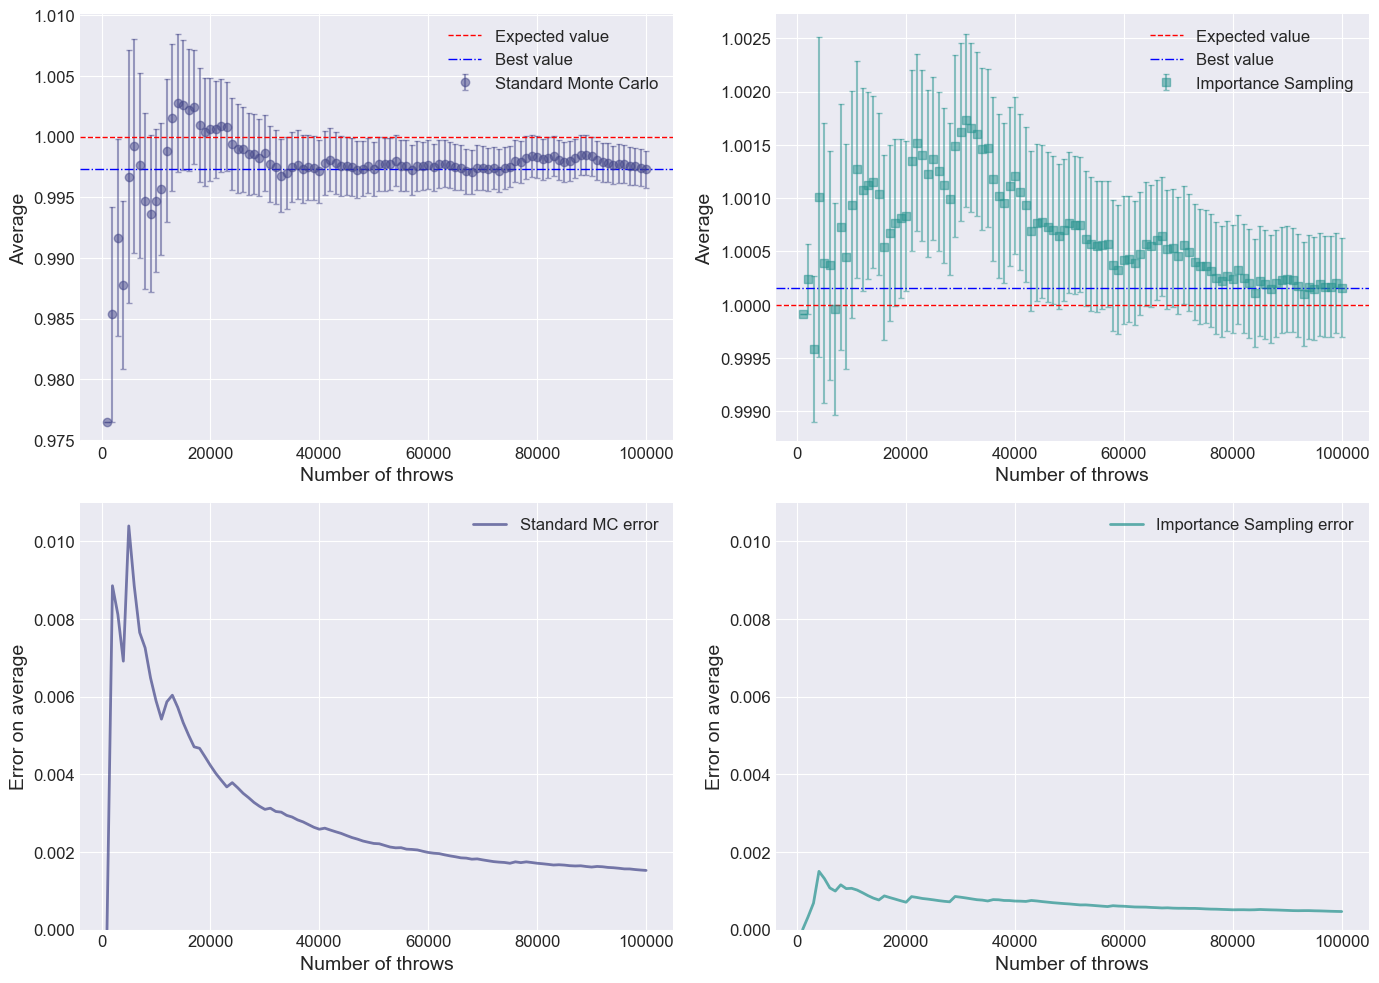

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

file_std = "Exercise_2_1/output_average.data"
file_imp = "Exercise_2_1/output_impsampling.data"
x1, y1, error1 = np.loadtxt(file_std, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(file_imp, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file_std, usecols=(0, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file_imp, usecols=(0, 2), delimiter='\t', unpack=True)

viridis = plt.cm.viridis
color_std = viridis(0.2)    
color_is = viridis(0.5)   
ref_color = 'red'
ref_color_2 = 'blue'

fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=100)

# Standard Monte Carlo - media
axs[0, 0].errorbar(x1, y1, yerr=error1, fmt='o', color=color_std,
                   capsize=2, elinewidth=1.5, alpha=0.5, label='Standard Monte Carlo')
axs[0, 0].axhline(y=1, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
axs[0, 0].axhline(y=y1[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
axs[0, 0].set_xlabel('Number of throws')
axs[0, 0].set_ylabel('Average')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Importance Sampling - media
axs[0, 1].errorbar(x2, y2, yerr=error2, fmt='s', color=color_is,
                   capsize=2, elinewidth=1.5, alpha=0.5, label='Importance Sampling')
axs[0, 1].axhline(y=1, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
axs[0, 1].axhline(y=y2[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
axs[0, 1].set_xlabel('Number of throws')
axs[0, 1].set_ylabel('Average')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Standard Monte Carlo - errore
axs[1, 0].plot(x3, y3, '-', color=color_std, alpha=0.7, label='Standard MC error')
axs[1, 0].set_xlabel('Number of throws')
axs[1, 0].set_ylabel('Error on average')
axs[1, 0].set_ylim([0, 0.011])
axs[1, 0].legend()
axs[1, 0].grid(True)

# Importance Sampling - errore
axs[1, 1].plot(x4, y4, '-', color=color_is, alpha=0.7, label='Importance Sampling error')
axs[1, 1].set_xlabel('Number of throws')
axs[1, 1].set_ylabel('Error on average')
axs[1, 1].legend()
axs[1, 1].set_ylim([0, 0.011])
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


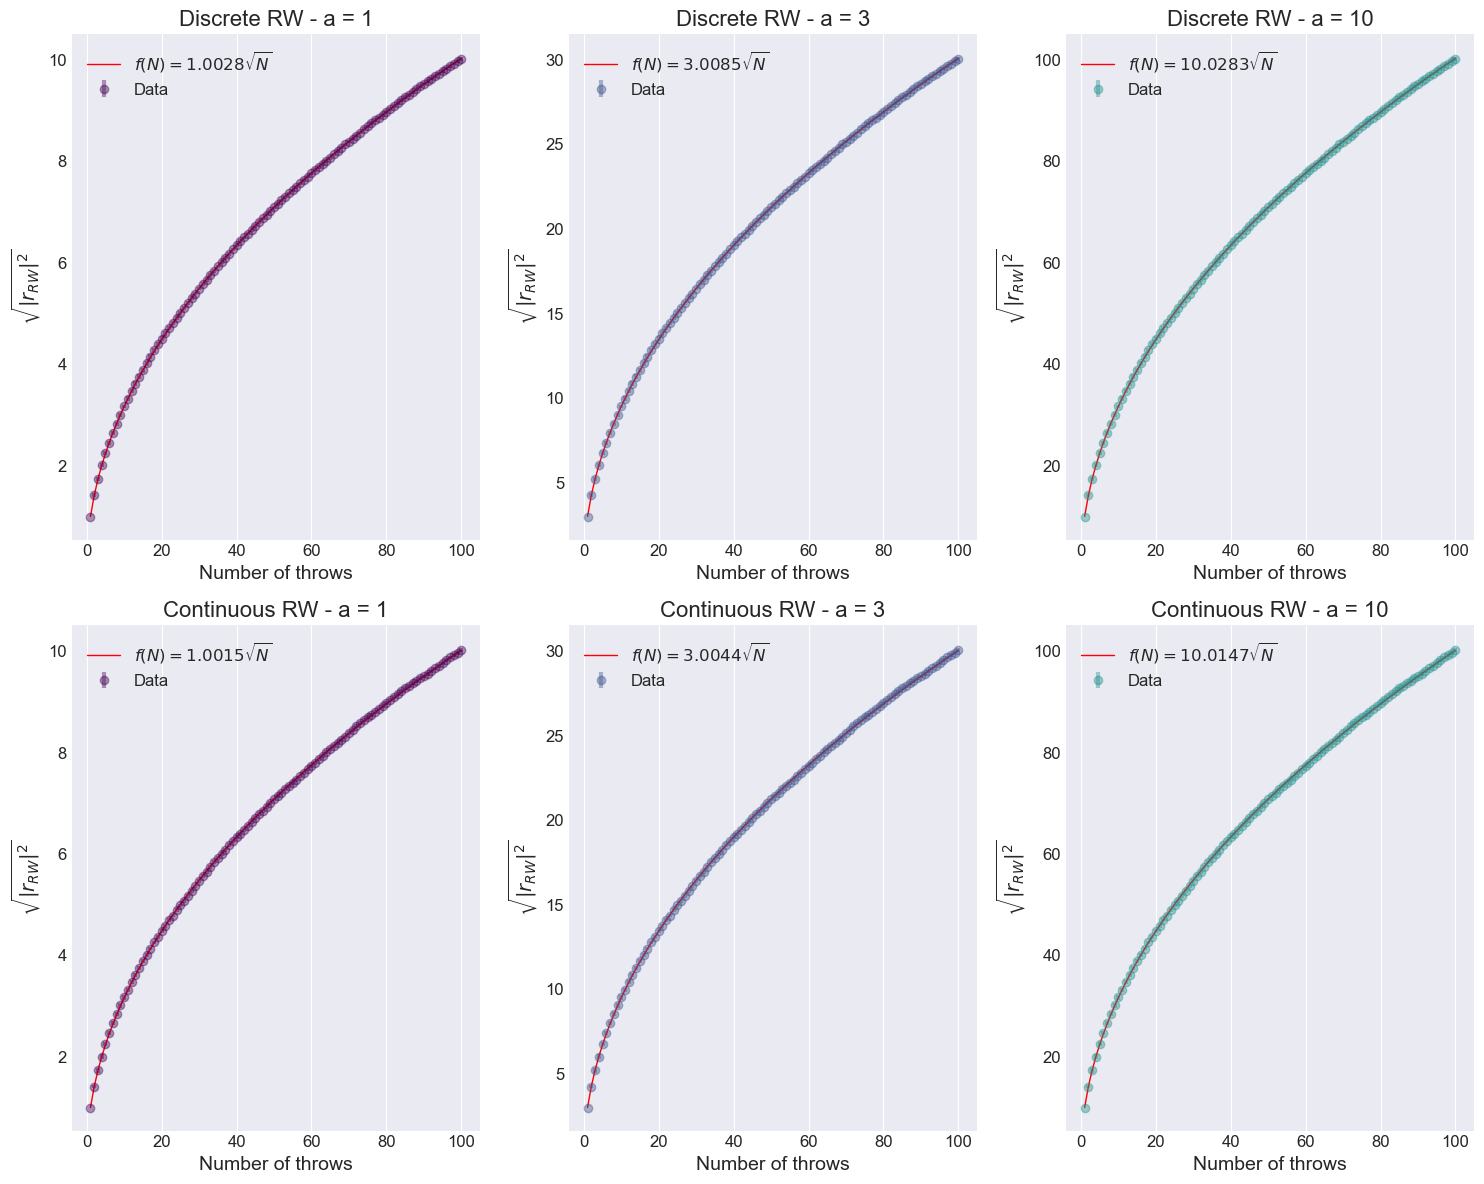

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def fit_func(x, k):
    return k * np.sqrt(x)

viridis = plt.cm.viridis(np.linspace(0, 1, 5))

files_discrete = [
    "Exercise_2_2/output_RW_discrete_1.000000.data",
    "Exercise_2_2/output_RW_discrete_3.000000.data",
    "Exercise_2_2/output_RW_discrete_10.000000.data"
]

files_continuous = [
    "Exercise_2_2/output_RW_continuous_1.000000.data",
    "Exercise_2_2/output_RW_continuous_3.000000.data",
    "Exercise_2_2/output_RW_continuous_10.000000.data"
]

labels_a = ['a = 1', 'a = 3', 'a = 10']

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

for i in range(3):
    x_d, y_d, err_d = np.loadtxt(files_discrete[i], usecols=(0, 1, 2), delimiter='\t', unpack=True)
    popt_d, _ = curve_fit(fit_func, x_d[1:], y_d[1:], sigma=err_d[1:], absolute_sigma=True)

    x_c, y_c, err_c = np.loadtxt(files_continuous[i], usecols=(0, 1, 2), delimiter='\t', unpack=True)
    popt_c, _ = curve_fit(fit_func, x_c[1:], y_c[1:], sigma=err_c[1:], absolute_sigma=True)

    ax_d = axes[0, i]
    ax_d.errorbar(x_d, y_d, yerr=err_d, fmt='o', markersize=6, color=viridis[i], capsize=0, elinewidth=3, alpha=0.4, label='Data')
    ax_d.plot(x_d, fit_func(x_d, *popt_d), 'r-',linewidth=1,
              label=rf'$f(N) = {popt_d[0]:.4f} \sqrt{{N}}$')
    ax_d.set_xlabel('Number of throws')
    ax_d.set_ylabel(r'$\sqrt{|r_{RW}|^2}$')
    ax_d.set_title(f'Discrete RW - {labels_a[i]}')
    ax_d.grid(axis='y')
    ax_d.legend()

    ax_c = axes[1, i]
    ax_c.errorbar(x_c, y_c, yerr=err_c, fmt='o', markersize=6, color=viridis[i], capsize=0, elinewidth=3, alpha=0.4, label='Data')
    ax_c.plot(x_c, fit_func(x_c, *popt_c), 'r-',linewidth=1,
              label=rf'$f(N) = {popt_c[0]:.4f} \sqrt{{N}}$')
    ax_c.set_xlabel('Number of throws')
    ax_c.set_ylabel(r'$\sqrt{|r_{RW}|^2}$')
    ax_c.set_title(f'Continuous RW - {labels_a[i]}')
    ax_c.grid(axis='y')
    ax_c.legend()

plt.tight_layout()
plt.show()


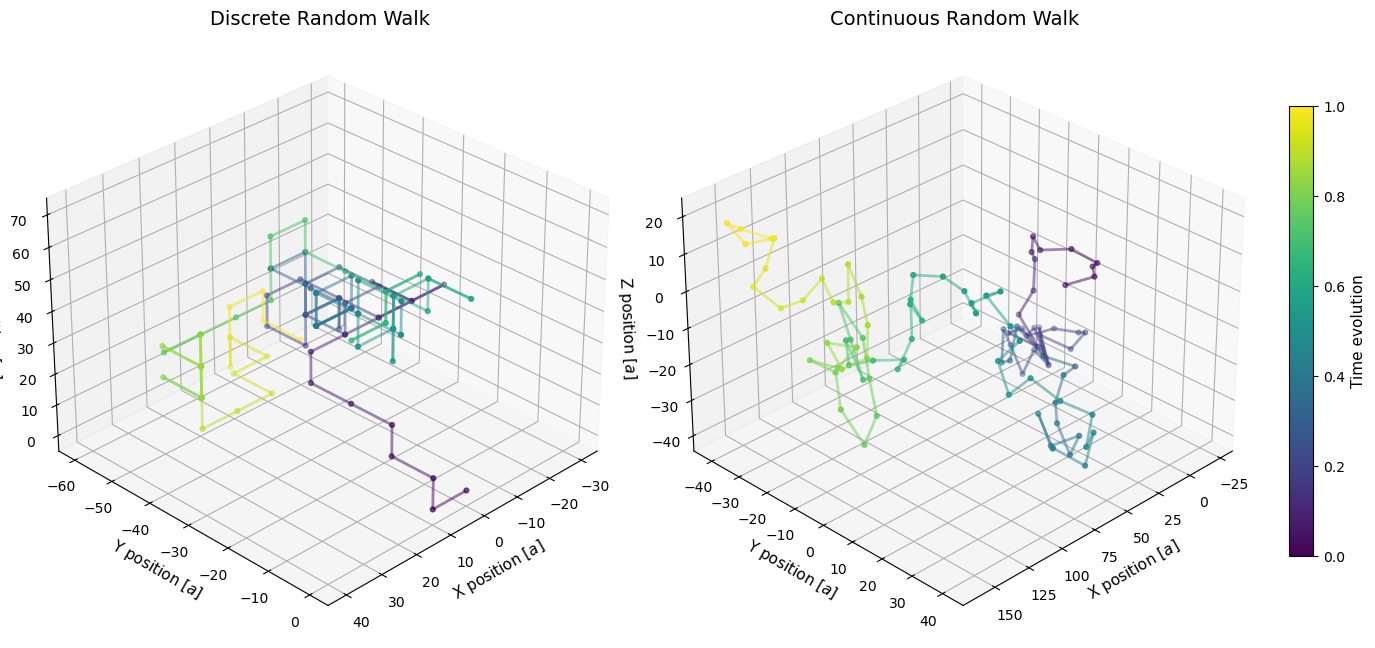

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec

def make_colored_line(ax, data, cmap='viridis', linewidth=1, alpha=0.6):
    # Prendi tutte le righe e solo le colonne 1, 2 e 3 (x, y, z)
    points = data[:, 1:4]
    segments = np.array([points[:-1], points[1:]]).transpose(1, 0, 2)
    colors = np.linspace(0, 1, len(points) - 1)
    lc = Line3DCollection(segments, cmap=cmap, array=colors,
                          linewidth=linewidth, alpha=alpha)
    ax.add_collection3d(lc)
    return lc

# Carica i dati dei random walks
data_1s = np.loadtxt("Exercise_2_2/trajectory_discrete.dat")  # Discrete RW
data_2p = np.loadtxt("Exercise_2_2/trajectory_continuous.dat")  # Continuous RW

# Stile del grafico
plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # Layout con 2 grafici

cmap = "viridis"
colors_1 = np.linspace(0, 1, len(data_1s))
colors_2 = np.linspace(0, 1, len(data_2p))

# Grafico per il Discrete Random Walk
ax1 = fig.add_subplot(gs[0], projection='3d')

# Usa tutte le righe e le colonne 1, 2, 3 per x, y, z (escludendo la prima colonna)
sc1 = ax1.scatter(data_1s[:, 1], data_1s[:, 2], data_1s[:, 3],
                  c=colors_1, cmap=cmap, s=12)

# Aggiungi la linea colorata per la traiettoria
make_colored_line(ax1, data_1s, cmap=cmap, linewidth=2, alpha=0.5)

# Etichette e titolo del grafico
ax1.set_title("Discrete Random Walk", fontsize=14, color='black')
ax1.set_xlabel("X position [$a$]", fontsize=11)
ax1.set_ylabel("Y position [$a$]", fontsize=11)
ax1.set_zlabel("Z position [$a$]", fontsize=11)
ax1.view_init(elev=30, azim=45)

# Grafico per il Continuous Random Walk
ax2 = fig.add_subplot(gs[1], projection='3d')

# Usa tutte le righe e le colonne 1, 2, 3 per x, y, z (escludendo la prima colonna)
sc2 = ax2.scatter(data_2p[:, 1], data_2p[:, 2], data_2p[:, 3],
                  c=colors_2, cmap=cmap, s=12)

# Aggiungi la linea colorata per la traiettoria
make_colored_line(ax2, data_2p, cmap=cmap, linewidth=2, alpha=0.5)

# Etichette e titolo del grafico
ax2.set_title("Continuous Random Walk", fontsize=14, color='black')
ax2.set_xlabel("X position [$a$]", fontsize=11)
ax2.set_ylabel("Y position [$a$]", fontsize=11)
ax2.set_zlabel("Z position [$a$]", fontsize=11)
ax2.view_init(elev=30, azim=45)

# Barra di colore per il tempo di evoluzione
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

# Aggiusta il layout dei grafici
plt.subplots_adjust(wspace=0.05, right=0.9)

# Mostra il grafico
plt.show()


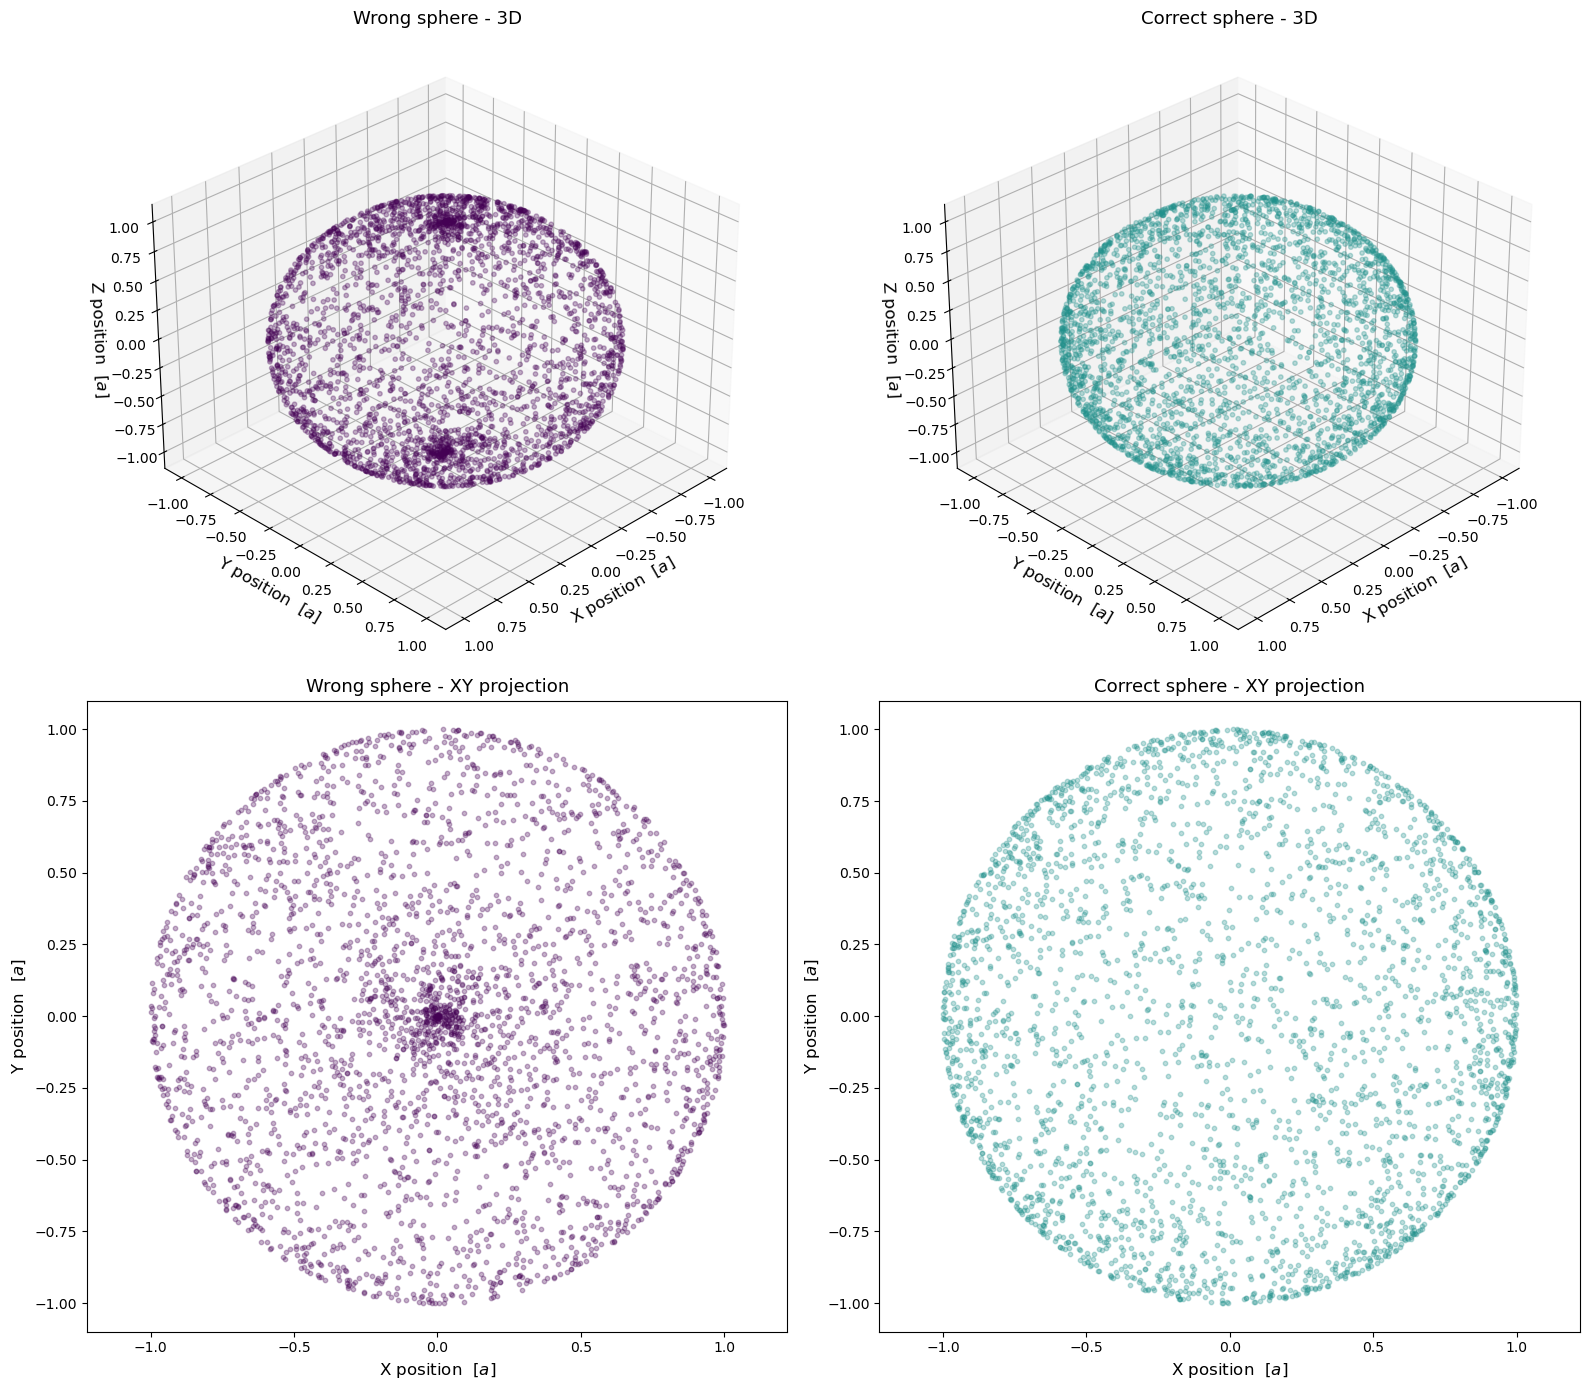

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data_1s = np.loadtxt("Exercise_2_2/sphere_wrong.dat")
data_2p = np.loadtxt("Exercise_2_2/sphere_correct.dat")

fig = plt.figure(figsize=(16, 14))

viridis = plt.cm.viridis(np.linspace(0, 1, 5))

plt.style.use('default')

# Subplot 1: Wrong sphere - 3D
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2], color=viridis[0], s=10, alpha=0.3)
ax1.set_title("Wrong sphere - 3D", fontsize=13)
ax1.set_xlabel("X position  [$a$]", fontsize=12)
ax1.set_ylabel("Y position  [$a$]", fontsize=12)
ax1.set_zlabel("Z position  [$a$]", fontsize=12)
ax1.view_init(elev=30, azim=45)

# Subplot 2: Correct sphere - 3D
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2], color=viridis[2], s=10, alpha=0.3)
ax2.set_title("Correct sphere - 3D", fontsize=13)
ax2.set_xlabel("X position  [$a$]", fontsize=12)
ax2.set_ylabel("Y position  [$a$]", fontsize=12)
ax2.set_zlabel("Z position  [$a$]", fontsize=12)
ax2.view_init(elev=30, azim=45)

# Subplot 3: Wrong sphere - XY projection
ax3 = fig.add_subplot(223)
ax3.scatter(data_1s[:, 0], data_1s[:, 1], color=viridis[0], s=10, alpha=0.3)
ax3.set_title("Wrong sphere - XY projection", fontsize=13)
ax3.set_xlabel("X position  [$a$]", fontsize=12)
ax3.set_ylabel("Y position  [$a$]", fontsize=12)
ax3.axis('equal')

# Subplot 4: Correct sphere - XY projection
ax4 = fig.add_subplot(224)
ax4.scatter(data_2p[:, 0], data_2p[:, 1], color=viridis[2], s=10, alpha=0.3)
ax4.set_title("Correct sphere - XY projection", fontsize=13)
ax4.set_xlabel("X position  [$a$]", fontsize=12)
ax4.set_ylabel("Y position  [$a$]", fontsize=12)
ax4.axis('equal')

plt.tight_layout()
plt.show()
